# Phan tich dac tinh du lieu theo tinh de giai thich khi LSTM/Transformer vuot Mamba

Notebook nay dung de tao minh chung du lieu cho cau hoi: vi sao o mot so tinh nhu Da Nang hoac Can Tho, LSTM/Transformer co the tot hon Mamba.

Y tuong chinh:
- Khong ket luan bang cam tinh. Notebook doc truc tiep `metrics.json` va `test_predictions.csv` tu nguon duoc cau hinh.
- Tai tao chuoi AQI test theo tung tinh tu `y_true` trong prediction file.
- Tinh cac dac tinh du lieu: do bien dong, spike, doi huong, tu tuong quan 24h/168h, do lech phan phoi, do kho theo horizon.
- Noi cac dac tinh do voi `delta_mae_vs_mamba`: neu delta am nghia la model dang tot hon Mamba.
- Co phan optional doc Gold/MinIO neu moi truong dang bat MinIO de bo sung chat luong du lieu va feature goc.

> Luu y: notebook nay cung cap bang chung dinh luong va gia thuyet co kiem chung, khong khang dinh nguyen nhan tuyet doi neu chua co them thi nghiem ablation.

In [5]:
from __future__ import annotations

import json
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    plt = None
    HAS_MATPLOTLIB = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "eda":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name.lower() == "dataset":
    PROJECT_ROOT = PROJECT_ROOT.parent

RUN_ROOT = PROJECT_ROOT / "runs" / "mamba_api"
LOCATIONS_PATH = PROJECT_ROOT / "DataSet" / "locations.jsonl"

FOCUS_PROVINCES = ["da_nang", "can_tho"]
COMPARE_PROVINCES = ["ha_noi", "ho_chi_minh", "da_nang", "can_tho", "hai_phong", "dong_nai"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUN_ROOT exists:", RUN_ROOT.exists())
print("matplotlib available:", HAS_MATPLOTLIB)

PROJECT_ROOT: d:\KLTN\Project
RUN_ROOT exists: True
matplotlib available: True


## Cau hinh nguon metric

- `METRIC_SOURCE = "local"`: doc tu `runs/mamba_api` trong may.
- `METRIC_SOURCE = "minio"`: doc tu bucket artifacts tren MinIO, dang `model/province=<province>/run_id=<run_id>/metrics.json`.

Neu MinIO khong ket noi duoc, notebook se bao loi ro rang de tranh am tham dung nham nguon.

In [6]:
METRIC_SOURCE = "minio"  # "minio" or "local"
MINIO_ARTIFACTS_BUCKET_OVERRIDE = None  # None = use env/default bucket
MINIO_RUN_ID_CONTAINS = "manual_latest"  # filter run_id; set None to read all
MINIO_PREFER_SINGLE_UNDERSCORE_RUN_ID = True

print("Metric source:", METRIC_SOURCE)

Metric source: minio


## 1. Doc metadata tinh va ket qua model

In [7]:
def load_locations(path: Path) -> pd.DataFrame:
    rows = []
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


locations = load_locations(LOCATIONS_PATH)
location_name = dict(zip(locations["location_key"], locations["name"]))
locations.head()

,location_key,name,latitude,longitude,timezone
0,ha_noi,TP. Hà Nội,21.0285,105.8542,Asia/Bangkok
1,ho_chi_minh,TP. Hồ Chí Minh,10.8231,106.6297,Asia/Bangkok
2,hai_phong,TP. Hải Phòng,20.8449,106.6881,Asia/Bangkok
3,da_nang,TP. Đà Nẵng,16.0544,108.2022,Asia/Bangkok
4,can_tho,TP. Cần Thơ,10.0452,105.7469,Asia/Bangkok


In [8]:
KNOWN_PROVINCES = sorted(locations["location_key"].astype(str).tolist(), key=len, reverse=True)


def parse_local_run_dir(path: Path) -> dict | None:
    """Parse local run dirs like mamba_manual_latest_can_tho or mamba_manual_latest__can_tho."""
    name = path.name
    for model in ["transformer", "mamba", "lstm"]:
        prefix = f"{model}_"
        if not name.startswith(prefix):
            continue
        rest = name[len(prefix):]
        for province in KNOWN_PROVINCES:
            for sep in ["__", "_"]:
                suffix = f"{sep}{province}"
                if rest.endswith(suffix):
                    tag = rest[: -len(suffix)]
                    if tag:
                        sep_type = "double_underscore" if sep == "__" else "single_underscore"
                        sep_priority = 1 if sep == "_" else 0
                        return {"model": model, "tag": tag, "province": province, "sep_type": sep_type, "sep_priority": sep_priority}
    return None


# Backward-compatible alias used in earlier test cells.
parse_run_dir = parse_local_run_dir


def parse_minio_artifact_path(object_name: str) -> dict | None:
    """Parse MinIO keys: model/province=<province>/run_id=<run_id>/metrics.json."""
    parts = object_name.split("/")
    if len(parts) < 4 or parts[-1] != "metrics.json":
        return None
    model = parts[0]
    if model not in {"mamba", "lstm", "transformer"}:
        return None
    province_part = next((x for x in parts if x.startswith("province=")), None)
    run_part = next((x for x in parts if x.startswith("run_id=")), None)
    if province_part is None or run_part is None:
        return None
    province = province_part.split("=", 1)[1]
    run_id = run_part.split("=", 1)[1]
    if province not in set(KNOWN_PROVINCES):
        return None
    sep_type = "single_underscore" if run_id.endswith(f"_{province}") and not run_id.endswith(f"__{province}") else "unknown_or_double"
    sep_priority = 1 if sep_type == "single_underscore" else 0
    tag = run_id
    for sep in ["__", "_"]:
        suffix = f"{sep}{province}"
        if run_id.endswith(suffix):
            tag = run_id[: -len(suffix)] or run_id
            break
    return {
        "model": model,
        "tag": tag,
        "province": province,
        "run_id": run_id,
        "sep_type": sep_type,
        "sep_priority": sep_priority,
        "object_name": object_name,
        "run_dir": f"s3://{{bucket}}/" + "/".join(parts[:-1]),
    }


def read_local_metrics(run_root: Path) -> pd.DataFrame:
    rows = []
    for run_dir in sorted(run_root.iterdir() if run_root.exists() else []):
        if not run_dir.is_dir():
            continue
        parsed = parse_local_run_dir(run_dir)
        metrics_path = run_dir / "metrics.json"
        if parsed is None or not metrics_path.exists():
            continue
        with metrics_path.open(encoding="utf-8") as f:
            metrics = json.load(f)
        rows.append({
            "source": "local",
            "run_id": run_dir.name,
            "run_dir": str(run_dir),
            **parsed,
            **metrics,
        })
    out = pd.DataFrame(rows)
    if out.empty:
        raise FileNotFoundError(f"Cannot find metrics.json in {run_root}")
    return out


def make_minio_client():
    import os
    import urllib3
    from minio import Minio

    access = os.environ.get("MINIO_ACCESS_KEY", "admin")
    secret = os.environ.get("MINIO_SECRET_KEY", "admin123")
    secure = os.environ.get("MINIO_SECURE", "false").lower() == "true"
    bucket = MINIO_ARTIFACTS_BUCKET_OVERRIDE or os.environ.get("MINIO_ARTIFACTS_BUCKET", "air-quality-artifacts")

    env_host = os.environ.get("MINIO_HOST")
    candidates = []
    if env_host:
        candidates.append(env_host)
    candidates.extend(["127.0.0.1:9004", "localhost:9004", "minio:9000"])

    # Keep order but remove duplicates.
    candidates = list(dict.fromkeys(candidates))
    errors = []
    for host in candidates:
        try:
            http_client = urllib3.PoolManager(
                timeout=urllib3.Timeout(connect=2.0, read=5.0),
                retries=urllib3.Retry(total=1, backoff_factor=0.2),
            )
            client = Minio(host, access_key=access, secret_key=secret, secure=secure, http_client=http_client)
            client.bucket_exists(bucket)
            print(f"MinIO endpoint dang dung: {host} | bucket={bucket}")
            return client, bucket
        except Exception as exc:
            errors.append(f"{host}: {type(exc).__name__}: {exc}")

    raise RuntimeError(
        "Khong ket noi duoc MinIO artifacts bucket. Da thu cac endpoint:\n- " + "\n- ".join(errors)
    )


def read_minio_metrics() -> pd.DataFrame:
    client, bucket = make_minio_client()
    rows = []
    for obj in client.list_objects(bucket, recursive=True):
        parsed = parse_minio_artifact_path(obj.object_name)
        if parsed is None:
            continue
        if MINIO_RUN_ID_CONTAINS and MINIO_RUN_ID_CONTAINS not in parsed.get("run_id", ""):
            continue
        resp = client.get_object(bucket, obj.object_name)
        try:
            metrics = json.loads(resp.read().decode("utf-8"))
        finally:
            resp.close()
            resp.release_conn()
        parsed["run_dir"] = parsed["run_dir"].format(bucket=bucket)
        rows.append({"source": "minio", "bucket": bucket, **parsed, **metrics})
    out = pd.DataFrame(rows)
    if out.empty:
        raise FileNotFoundError(
            f"Cannot find metrics.json on MinIO bucket={bucket} with run_id filter={MINIO_RUN_ID_CONTAINS!r}"
        )
    return out


def read_metrics() -> pd.DataFrame:
    if METRIC_SOURCE == "minio":
        return read_minio_metrics()
    if METRIC_SOURCE == "local":
        return read_local_metrics(RUN_ROOT)
    raise ValueError('METRIC_SOURCE must be "minio" or "local"')


metrics_all = read_metrics()
metrics_all["province_name"] = metrics_all["province"].map(location_name).fillna(metrics_all["province"])
print("Metric source rows:", len(metrics_all), "| source:", METRIC_SOURCE)
display(metrics_all.sort_values(["province", "model", "tag"]).head(20))


MinIO endpoint dang dung: 127.0.0.1:9004 | bucket=air-quality-artifacts
Metric source rows: 204 | source: minio


,source,bucket,model,tag,province,run_id,sep_type,sep_priority,object_name,run_dir,val_norm_mae,val_norm_mse,val_norm_rmse,val_norm_r2,test_norm_mae,test_norm_mse,test_norm_rmse,test_norm_r2,best_epoch,final_gap,province_name
0,minio,air-quality-artifacts,lstm,lstm_manual_latest,an_giang,lstm_manual_latest__an_giang,unknown_or_double,0,lstm/province=an_giang/run_id=lstm_manual_late...,s3://air-quality-artifacts/lstm/province=an_gi...,0.163562,0.063100,0.251198,0.870708,0.192890,0.085097,0.291714,0.817601,19,0.035520,An Giang
1,minio,air-quality-artifacts,lstm,lstm_manual_latest,an_giang,lstm_manual_latest_an_giang,single_underscore,1,lstm/province=an_giang/run_id=lstm_manual_late...,s3://air-quality-artifacts/lstm/province=an_gi...,0.163562,0.063100,0.251198,0.870708,0.192890,0.085097,0.291714,0.817601,19,0.035520,An Giang
68,minio,air-quality-artifacts,mamba,mamba_manual_latest,an_giang,mamba_manual_latest__an_giang,unknown_or_double,0,mamba/province=an_giang/run_id=mamba_manual_la...,s3://air-quality-artifacts/mamba/province=an_g...,0.138399,0.046835,0.216413,0.875047,0.149140,0.060706,0.246385,0.893463,31,0.021647,An Giang
69,minio,air-quality-artifacts,mamba,mamba_manual_latest,an_giang,mamba_manual_latest_an_giang,single_underscore,1,mamba/province=an_giang/run_id=mamba_manual_la...,s3://air-quality-artifacts/mamba/province=an_g...,0.130164,0.040317,0.200792,0.917390,0.143367,0.054395,0.233227,0.883409,28,0.018577,An Giang
136,minio,air-quality-artifacts,transformer,transformer_manual_latest,an_giang,transformer_manual_latest__an_giang,unknown_or_double,0,transformer/province=an_giang/run_id=transform...,s3://air-quality-artifacts/transformer/provinc...,0.147005,0.051979,0.227989,0.893495,0.178778,0.080680,0.284042,0.827069,58,0.014985,An Giang
137,minio,air-quality-artifacts,transformer,transformer_manual_latest,an_giang,transformer_manual_latest_an_giang,single_underscore,1,transformer/province=an_giang/run_id=transform...,s3://air-quality-artifacts/transformer/provinc...,0.147005,0.051979,0.227989,0.893495,0.178778,0.080680,0.284042,0.827070,58,0.014985,An Giang
2,minio,air-quality-artifacts,lstm,lstm_manual_latest,bac_ninh,lstm_manual_latest__bac_ninh,unknown_or_double,0,lstm/province=bac_ninh/run_id=lstm_manual_late...,s3://air-quality-artifacts/lstm/province=bac_n...,0.151199,0.050036,0.223688,0.939113,0.277897,0.181618,0.426167,0.835153,7,0.031084,Bắc Ninh
3,minio,air-quality-artifacts,lstm,lstm_manual_latest,bac_ninh,lstm_manual_latest_bac_ninh,single_underscore,1,lstm/province=bac_ninh/run_id=lstm_manual_late...,s3://air-quality-artifacts/lstm/province=bac_n...,0.151199,0.050036,0.223688,0.939113,0.277897,0.181618,0.426167,0.835153,7,0.031084,Bắc Ninh
70,minio,air-quality-artifacts,mamba,mamba_manual_latest,bac_ninh,mamba_manual_latest__bac_ninh,unknown_or_double,0,mamba/province=bac_ninh/run_id=mamba_manual_la...,s3://air-quality-artifacts/mamba/province=bac_...,0.170588,0.059963,0.244873,0.910733,0.284182,0.179462,0.423630,0.829980,10,0.040521,Bắc Ninh
71,minio,air-quality-artifacts,mamba,mamba_manual_latest,bac_ninh,mamba_manual_latest_bac_ninh,single_underscore,1,mamba/province=bac_ninh/run_id=mamba_manual_la...,s3://air-quality-artifacts/mamba/province=bac_...,0.145164,0.049688,0.222907,0.939537,0.293342,0.208130,0.456213,0.811089,32,0.026580,Bắc Ninh


In [9]:
def choose_latest_manual_runs(metrics: pd.DataFrame) -> pd.DataFrame:
    """Æ¯u tiÃªn cÃ¡c run manual_latest Ä‘á»ƒ khá»›p báº£ng benchmark thá»§ cÃ´ng."""
    manual = metrics[metrics["tag"].str.contains("manual_latest", na=False)].copy()
    if manual.empty:
        manual = metrics.copy()
    if "sep_priority" not in manual.columns:
        manual["sep_priority"] = 0
    # If both manual_latest_can_tho and manual_latest__can_tho exist, prefer the single-underscore run id.
    manual = manual.sort_values(["province", "model", "tag", "sep_priority", "run_dir"])
    return manual.groupby(["province", "model"], as_index=False).tail(1).reset_index(drop=True)


metrics = choose_latest_manual_runs(metrics_all)
metric_cols = ["test_norm_mae", "test_norm_rmse", "test_norm_r2", "val_norm_mae", "val_norm_rmse", "val_norm_r2", "best_epoch", "final_gap"]
benchmark = metrics.pivot_table(index="province", columns="model", values=["test_norm_mae", "test_norm_rmse", "test_norm_r2"], aggfunc="first")
display(benchmark.loc[[p for p in COMPARE_PROVINCES if p in benchmark.index]])

winner = metrics.loc[metrics.groupby("province")["test_norm_mae"].idxmin(), ["province", "province_name", "model", "test_norm_mae", "test_norm_rmse", "test_norm_r2"]]
winner = winner.rename(columns={"model": "best_by_mae"}).sort_values("province")
display(winner[winner["province"].isin(COMPARE_PROVINCES)])

test_norm_mae                       test_norm_r2                       test_norm_rmse                      
model                lstm     mamba transformer         lstm     mamba transformer           lstm     mamba transformer
province                                                                                                               
ha_noi           0.280436  0.270151    0.277821     0.841154  0.827582    0.838001       0.418338  0.435844    0.422469
ho_chi_minh      0.234198  0.191855    0.192643     0.901068  0.933678    0.921121       0.374780  0.306858    0.334649
da_nang          0.326316  0.344588    0.299724     0.729588  0.671554    0.792798       0.552522  0.608931    0.483652
can_tho          0.172456  0.176960    0.192193     0.871262  0.847526    0.842788       0.249983  0.272054    0.276249
hai_phong        0.321995  0.227954    0.272048     0.707627  0.763919    0.678037       0.462779  0.415848    0.485632
dong_nai         0.198653  0.193382    0.213609     0.918106  0.922790    0.918918       0.336922  0.327145    0.335249

,province,province_name,best_by_mae,test_norm_mae,test_norm_rmse,test_norm_r2
9,can_tho,TP. Cần Thơ,lstm,0.172456,0.249983,0.871262
17,da_nang,TP. Đà Nẵng,transformer,0.299724,0.483652,0.792798
25,dong_nai,Đồng Nai,mamba,0.193382,0.327145,0.922790
34,ha_noi,TP. Hà Nội,mamba,0.270151,0.435844,0.827582
40,hai_phong,TP. Hải Phòng,mamba,0.227954,0.415848,0.763919
43,ho_chi_minh,TP. Hồ Chí Minh,mamba,0.191855,0.306858,0.933678


### Tuy chon: dung dung bang benchmark trong anh

Neu thay dang doi chieu theo bang anh, dat `USE_SCREENSHOT_BENCHMARK = True`. Khi do notebook van dung prediction files de phan tich dac tinh chuoi, nhung bang thang-thua se lay dung metric trong anh de dien giai.

In [10]:
USE_SCREENSHOT_BENCHMARK = False

screenshot_rows = [
    {"province": "ha_noi", "model": "mamba", "test_norm_mae": 0.2515, "test_norm_rmse": 0.3846, "test_norm_r2": 0.8650},
    {"province": "ha_noi", "model": "lstm", "test_norm_mae": 0.2861, "test_norm_rmse": 0.4267, "test_norm_r2": 0.8338},
    {"province": "ha_noi", "model": "transformer", "test_norm_mae": 0.2780, "test_norm_rmse": 0.4142, "test_norm_r2": 0.8430},
    {"province": "ho_chi_minh", "model": "mamba", "test_norm_mae": 0.1918, "test_norm_rmse": 0.3068, "test_norm_r2": 0.9336},
    {"province": "ho_chi_minh", "model": "lstm", "test_norm_mae": 0.2342, "test_norm_rmse": 0.3748, "test_norm_r2": 0.9010},
    {"province": "ho_chi_minh", "model": "transformer", "test_norm_mae": 0.1926, "test_norm_rmse": 0.3346, "test_norm_r2": 0.9211},
    {"province": "da_nang", "model": "mamba", "test_norm_mae": 0.3446, "test_norm_rmse": 0.6089, "test_norm_r2": 0.6716},
    {"province": "da_nang", "model": "lstm", "test_norm_mae": 0.3263, "test_norm_rmse": 0.5525, "test_norm_r2": 0.7296},
    {"province": "da_nang", "model": "transformer", "test_norm_mae": 0.2997, "test_norm_rmse": 0.4836, "test_norm_r2": 0.7927},
    {"province": "can_tho", "model": "mamba", "test_norm_mae": 0.1769, "test_norm_rmse": 0.2720, "test_norm_r2": 0.8476},
    {"province": "can_tho", "model": "lstm", "test_norm_mae": 0.1725, "test_norm_rmse": 0.2499, "test_norm_r2": 0.8712},
    {"province": "can_tho", "model": "transformer", "test_norm_mae": 0.1921, "test_norm_rmse": 0.2762, "test_norm_r2": 0.8427},
    {"province": "hai_phong", "model": "mamba", "test_norm_mae": 0.2280, "test_norm_rmse": 0.4162, "test_norm_r2": 0.7635},
    {"province": "hai_phong", "model": "lstm", "test_norm_mae": 0.3219, "test_norm_rmse": 0.4627, "test_norm_r2": 0.7076},
    {"province": "hai_phong", "model": "transformer", "test_norm_mae": 0.2720, "test_norm_rmse": 0.4856, "test_norm_r2": 0.6780},
    {"province": "dong_nai", "model": "mamba", "test_norm_mae": 0.1933, "test_norm_rmse": 0.3271, "test_norm_r2": 0.9228},
    {"province": "dong_nai", "model": "lstm", "test_norm_mae": 0.1986, "test_norm_rmse": 0.3369, "test_norm_r2": 0.9181},
    {"province": "dong_nai", "model": "transformer", "test_norm_mae": 0.2136, "test_norm_rmse": 0.3352, "test_norm_r2": 0.9189},
]

if USE_SCREENSHOT_BENCHMARK:
    screenshot_metrics = pd.DataFrame(screenshot_rows)
    keep_cols = ["province", "model", "tag", "run_dir", "province_name", "val_norm_mae", "best_epoch", "final_gap"]
    run_refs = metrics[[c for c in keep_cols if c in metrics.columns]].drop_duplicates(["province", "model"])
    metrics = screenshot_metrics.merge(run_refs, on=["province", "model"], how="left")
    metrics["province_name"] = metrics["province"].map(location_name).fillna(metrics["province"])
    print("Using benchmark metrics entered from the screenshot table.")
else:
    print(f"Using metrics from source: {METRIC_SOURCE}.")

Using metrics from source: minio.


## 2. Tai tao chuoi AQI test tu prediction files

`test_predictions.csv` co nhieu dong trung mot timestamp do sliding window. De phan tich dac tinh chuoi, ta gom theo `province,time` va lay median cua `y_true`.

In [11]:
def read_predictions_for_selected_runs(metrics: pd.DataFrame) -> pd.DataFrame:
    frames = []
    if METRIC_SOURCE == "minio":
        client, default_bucket = make_minio_client()
        for row in metrics.itertuples(index=False):
            bucket = getattr(row, "bucket", None) or default_bucket
            if bucket is None:
                run_dir = str(row.run_dir)
                bucket = run_dir.replace("s3://", "").split("/", 1)[0]
            prefix = str(row.run_dir).replace(f"s3://{bucket}/", "")
            path = f"{prefix}/test_predictions.csv"
            try:
                resp = client.get_object(bucket, path)
                try:
                    raw = resp.read()
                finally:
                    resp.close()
                    resp.release_conn()
                import io
                df = pd.read_csv(io.BytesIO(raw))
            except Exception as exc:
                print(f"[WARN] Cannot read s3://{bucket}/{path}: {exc}")
                continue
            df["time"] = pd.to_datetime(df["time"], errors="coerce")
            df["model"] = row.model
            df["tag"] = row.tag
            df["province"] = row.province
            df["run_id"] = getattr(row, "run_id", row.tag)
            frames.append(df)
    else:
        for row in metrics.itertuples(index=False):
            path = Path(row.run_dir) / "test_predictions.csv"
            if not path.exists():
                continue
            df = pd.read_csv(path)
            df["time"] = pd.to_datetime(df["time"], errors="coerce")
            df["model"] = row.model
            df["tag"] = row.tag
            df["province"] = row.province
            df["run_id"] = getattr(row, "run_id", row.tag)
            frames.append(df)
    if not frames:
        raise FileNotFoundError("Cannot find test_predictions.csv for selected runs")
    return pd.concat(frames, ignore_index=True)


pred = read_predictions_for_selected_runs(metrics)
pred["province_name"] = pred["province"].map(location_name).fillna(pred["province"])
pred.head()


MinIO endpoint dang dung: 127.0.0.1:9004 | bucket=air-quality-artifacts


,split,sample_index,province,horizon_step,time,y_true,y_pred,error,abs_error,model,tag,run_id,province_name
0,test,0,an_giang,1,2026-03-03 10:00:00,89.0,88.612335,-0.387665,0.387665,lstm,lstm_manual_latest,lstm_manual_latest_an_giang,An Giang
1,test,0,an_giang,2,2026-03-03 11:00:00,89.0,89.648827,0.648827,0.648827,lstm,lstm_manual_latest,lstm_manual_latest_an_giang,An Giang
2,test,0,an_giang,3,2026-03-03 12:00:00,89.0,88.700035,-0.299965,0.299965,lstm,lstm_manual_latest,lstm_manual_latest_an_giang,An Giang
3,test,0,an_giang,4,2026-03-03 13:00:00,88.0,88.987061,0.987061,0.987061,lstm,lstm_manual_latest,lstm_manual_latest_an_giang,An Giang
4,test,0,an_giang,5,2026-03-03 14:00:00,87.0,89.712608,2.712608,2.712608,lstm,lstm_manual_latest,lstm_manual_latest_an_giang,An Giang


In [12]:
def reconstruct_target_series(predictions: pd.DataFrame) -> pd.DataFrame:
    base = predictions.dropna(subset=["time", "y_true"]).copy()
    series = (
        base.groupby(["province", "time"], as_index=False)
        .agg(
            aqi=("y_true", "median"),
            n_votes=("y_true", "size"),
        )
        .sort_values(["province", "time"])
        .reset_index(drop=True)
    )
    series["province_name"] = series["province"].map(location_name).fillna(series["province"])
    return series


target_series = reconstruct_target_series(pred)
display(target_series.groupby("province").agg(start=("time", "min"), end=("time", "max"), n_hours=("time", "nunique"), mean_aqi=("aqi", "mean")).reset_index())

,province,start,end,n_hours,mean_aqi
0,an_giang,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,92.552881
1,bac_ninh,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,128.581689
2,ca_mau,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,55.408840
3,can_tho,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,109.867403
4,cao_bang,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,88.393844
5,da_nang,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,103.381610
6,dak_lak,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,63.823599
7,dien_bien,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,85.681531
8,dong_nai,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,86.712313
9,dong_thap,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,91.806630


## 3. Tinh dac tinh du lieu theo tinh

In [13]:
def autocorr_at_lag(values: pd.Series, lag: int) -> float:
    x = pd.Series(values).astype(float)
    if len(x) <= lag or x.nunique(dropna=True) <= 1:
        return np.nan
    return float(x.autocorr(lag=lag))


def sign_change_rate(diff: pd.Series) -> float:
    s = np.sign(diff.dropna().to_numpy())
    s = s[s != 0]
    if len(s) < 2:
        return np.nan
    return float(np.mean(s[1:] != s[:-1]))


def entropy_from_hist(values: pd.Series, bins: int = 12) -> float:
    arr = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(arr) < 10:
        return np.nan
    counts, _ = np.histogram(arr, bins=bins)
    probs = counts[counts > 0] / counts.sum()
    return float(-(probs * np.log2(probs)).sum())


def max_gap_hours(times: pd.Series) -> float:
    t = pd.to_datetime(times).sort_values()
    if len(t) < 2:
        return np.nan
    return float(t.diff().dt.total_seconds().div(3600).max())


def province_series_features(series: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for province, g in series.groupby("province"):
        g = g.sort_values("time").copy()
        y = g["aqi"].astype(float)
        d1 = y.diff()
        abs_d1 = d1.abs()
        spike_threshold = max(10.0, float(abs_d1.quantile(0.90))) if abs_d1.notna().any() else 10.0
        hourly_gaps = g["time"].diff().dt.total_seconds().div(3600)
        expected_hours = max(1, int((g["time"].max() - g["time"].min()).total_seconds() / 3600) + 1)
        rows.append({
            "province": province,
            "province_name": location_name.get(province, province),
            "start": g["time"].min(),
            "end": g["time"].max(),
            "n_hours": int(g["time"].nunique()),
            "coverage_ratio": float(g["time"].nunique() / expected_hours),
            "max_gap_h": max_gap_hours(g["time"]),
            "aqi_mean": float(y.mean()),
            "aqi_std": float(y.std()),
            "aqi_cv": float(y.std() / y.mean()) if y.mean() else np.nan,
            "aqi_iqr": float(y.quantile(0.75) - y.quantile(0.25)),
            "aqi_skew": float(y.skew()),
            "aqi_kurtosis": float(y.kurtosis()),
            "diff_abs_mean": float(abs_d1.mean()),
            "diff_abs_p90": float(abs_d1.quantile(0.90)),
            "diff_abs_p95": float(abs_d1.quantile(0.95)),
            "spike_rate": float((abs_d1 >= spike_threshold).mean()),
            "spike_threshold": spike_threshold,
            "direction_change_rate": sign_change_rate(d1),
            "autocorr_1h": autocorr_at_lag(y, 1),
            "autocorr_12h": autocorr_at_lag(y, 12),
            "autocorr_24h": autocorr_at_lag(y, 24),
            "autocorr_168h": autocorr_at_lag(y, 168),
            "hist_entropy": entropy_from_hist(y),
        })
    return pd.DataFrame(rows)


data_features = province_series_features(target_series)
display(data_features[data_features["province"].isin(COMPARE_PROVINCES)].sort_values("province"))

,province,province_name,start,end,n_hours,coverage_ratio,max_gap_h,aqi_mean,aqi_std,aqi_cv,aqi_iqr,aqi_skew,aqi_kurtosis,diff_abs_mean,diff_abs_p90,diff_abs_p95,spike_rate,spike_threshold,direction_change_rate,autocorr_1h,autocorr_12h,autocorr_24h,autocorr_168h,hist_entropy
3,can_tho,TP. Cần Thơ,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,1.0,1.0,109.867403,24.439839,0.222449,31.00,0.337067,-0.380051,1.256218,3.0,4.0,0.012628,10.0,0.140132,0.994307,0.789679,0.564134,0.146421,3.296769
5,da_nang,TP. Đà Nẵng,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,1.0,1.0,103.381610,54.315916,0.525392,67.00,1.173417,0.404471,7.348204,24.0,30.0,0.102210,24.0,0.139607,0.973860,0.167822,0.813326,0.426925,2.991345
8,dong_nai,Đồng Nai,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,1.0,1.0,86.712313,29.866827,0.344436,42.00,0.964682,-0.174784,1.545598,3.0,8.0,0.041436,10.0,0.168024,0.991796,0.877343,0.834525,0.546970,3.061736
11,ha_noi,TP. Hà Nội,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,1.0,1.0,128.581689,37.207502,0.289369,57.75,0.530196,-0.107017,3.586656,11.0,19.0,0.103788,11.0,0.119957,0.979794,0.584926,0.637091,0.303166,2.956623
13,hai_phong,TP. Hải Phòng,2026-03-03 10:00:00,2026-06-16 23:00:00,2534,1.0,1.0,83.988950,29.366113,0.349643,37.00,1.477605,2.638671,2.828662,9.8,16.0,0.100237,10.0,0.124626,0.978214,0.434781,0.538127,0.153710,2.657267
14,ho_chi_minh,TP. Hồ Chí Minh,2026-03-04 01:00:00,2026-06-17 18:00:00,2538,1.0,1.0,87.324665,30.295643,0.346931,44.00,0.935740,-0.264466,1.549074,3.0,8.0,0.041371,10.0,0.168514,0.992023,0.880204,0.838498,0.569575,3.076081


### Dien giai nhanh cac feature

- `aqi_std`, `aqi_iqr`, `diff_abs_mean`, `diff_abs_p95`: chuoi bien dong manh hoac nhieu thay doi dot ngot.
- `spike_rate`: ty le gio co buoc nhay lon.
- `direction_change_rate`: chuoi doi huong lien tuc, kho cho mo hinh giu trang thai dai.
- `autocorr_24h`, `autocorr_168h`: chu ky ngay/tuan ro. Transformer thuong tan dung tot pattern theo vi tri/thoi gian; LSTM tot khi phu thuoc ngan han va muot.
- `coverage_ratio`, `max_gap_h`: du lieu thieu/gap lon co the lam sequence model nhay khac nhau.

## 4. Noi dac tinh du lieu voi chenh lech hieu nang so voi Mamba

In [14]:
perf = metrics[["province", "province_name", "model", "test_norm_mae", "test_norm_rmse", "test_norm_r2", "val_norm_mae", "best_epoch", "final_gap"]].copy()
mamba_perf = perf[perf["model"] == "mamba"][["province", "test_norm_mae", "test_norm_rmse", "test_norm_r2"]].rename(columns={
    "test_norm_mae": "mamba_mae",
    "test_norm_rmse": "mamba_rmse",
    "test_norm_r2": "mamba_r2",
})
perf_vs_mamba = perf.merge(mamba_perf, on="province", how="left")
perf_vs_mamba["delta_mae_vs_mamba"] = perf_vs_mamba["test_norm_mae"] - perf_vs_mamba["mamba_mae"]
perf_vs_mamba["delta_rmse_vs_mamba"] = perf_vs_mamba["test_norm_rmse"] - perf_vs_mamba["mamba_rmse"]
perf_vs_mamba["delta_r2_vs_mamba"] = perf_vs_mamba["test_norm_r2"] - perf_vs_mamba["mamba_r2"]
analysis = perf_vs_mamba.merge(data_features, on=["province", "province_name"], how="left")

focus_analysis = analysis[analysis["province"].isin(FOCUS_PROVINCES)].sort_values(["province", "delta_mae_vs_mamba"])
display(focus_analysis[[
    "province_name", "model", "test_norm_mae", "mamba_mae", "delta_mae_vs_mamba", "test_norm_rmse", "mamba_rmse", "delta_rmse_vs_mamba",
    "aqi_std", "diff_abs_mean", "diff_abs_p95", "spike_rate", "direction_change_rate", "autocorr_24h", "autocorr_168h", "coverage_ratio", "max_gap_h"
]])

,province_name,model,test_norm_mae,mamba_mae,delta_mae_vs_mamba,test_norm_rmse,mamba_rmse,delta_rmse_vs_mamba,aqi_std,diff_abs_mean,diff_abs_p95,spike_rate,direction_change_rate,autocorr_24h,autocorr_168h,coverage_ratio,max_gap_h
9,TP. Cần Thơ,lstm,0.172456,0.176960,-0.004504,0.249983,0.272054,-0.022071,24.439839,1.256218,4.0,0.012628,0.140132,0.564134,0.146421,1.0,1.0
10,TP. Cần Thơ,mamba,0.176960,0.176960,0.000000,0.272054,0.272054,0.000000,24.439839,1.256218,4.0,0.012628,0.140132,0.564134,0.146421,1.0,1.0
11,TP. Cần Thơ,transformer,0.192193,0.176960,0.015233,0.276249,0.272054,0.004195,24.439839,1.256218,4.0,0.012628,0.140132,0.564134,0.146421,1.0,1.0
17,TP. Đà Nẵng,transformer,0.299724,0.344588,-0.044864,0.483652,0.608931,-0.125279,54.315916,7.348204,30.0,0.102210,0.139607,0.813326,0.426925,1.0,1.0
15,TP. Đà Nẵng,lstm,0.326316,0.344588,-0.018271,0.552522,0.608931,-0.056409,54.315916,7.348204,30.0,0.102210,0.139607,0.813326,0.426925,1.0,1.0
16,TP. Đà Nẵng,mamba,0.344588,0.344588,0.000000,0.608931,0.608931,0.000000,54.315916,7.348204,30.0,0.102210,0.139607,0.813326,0.426925,1.0,1.0


In [15]:
feature_cols_for_corr = [
    "coverage_ratio", "max_gap_h", "aqi_std", "aqi_cv", "aqi_iqr", "aqi_skew", "aqi_kurtosis",
    "diff_abs_mean", "diff_abs_p90", "diff_abs_p95", "spike_rate", "direction_change_rate",
    "autocorr_1h", "autocorr_12h", "autocorr_24h", "autocorr_168h", "hist_entropy",
]

for model in ["lstm", "transformer"]:
    sub = analysis[analysis["model"] == model].dropna(subset=["delta_mae_vs_mamba"])
    corr_rows = []
    for col in feature_cols_for_corr:
        if col in sub and sub[col].notna().sum() >= 4:
            corr_rows.append({"model": model, "feature": col, "corr_with_delta_mae": sub[col].corr(sub["delta_mae_vs_mamba"])})
    corr_df = pd.DataFrame(corr_rows).sort_values("corr_with_delta_mae")
    print(f"\n{model.upper()} - correlation vá»›i delta_mae_vs_mamba (Ã¢m: feature cÃ ng cao, model cÃ ng cÃ³ xu hÆ°á»›ng tá»‘t hÆ¡n Mamba)")
    display(corr_df)


LSTM - correlation vá»›i delta_mae_vs_mamba (Ã¢m: feature cÃ ng cao, model cÃ ng cÃ³ xu hÆ°á»›ng tá»‘t hÆ¡n Mamba)


,model,feature,corr_with_delta_mae
16,lstm,hist_entropy,-0.297463
15,lstm,autocorr_168h,-0.164338
14,lstm,autocorr_24h,-0.138952
13,lstm,autocorr_12h,-0.136261
12,lstm,autocorr_1h,-0.121209
4,lstm,aqi_iqr,-0.068108
3,lstm,aqi_cv,-0.046109
2,lstm,aqi_std,-0.031178
7,lstm,diff_abs_mean,0.016394
11,lstm,direction_change_rate,0.037033



TRANSFORMER - correlation vá»›i delta_mae_vs_mamba (Ã¢m: feature cÃ ng cao, model cÃ ng cÃ³ xu hÆ°á»›ng tá»‘t hÆ¡n Mamba)


,model,feature,corr_with_delta_mae
14,transformer,autocorr_24h,-0.369535
15,transformer,autocorr_168h,-0.349890
3,transformer,aqi_cv,-0.308637
16,transformer,hist_entropy,-0.158982
2,transformer,aqi_std,-0.148334
4,transformer,aqi_iqr,-0.126593
13,transformer,autocorr_12h,-0.074882
7,transformer,diff_abs_mean,-0.058921
8,transformer,diff_abs_p90,-0.044714
9,transformer,diff_abs_p95,-0.033465


## 5. Phan tich loi theo horizon va theo vung bien dong

Neu Mamba kem hon chu yeu o horizon xa hoac o cac doan spike/doi huong, day la bang chung tot de giai thich bang dac tinh chuoi.

In [16]:
horizon_err = (
    pred.groupby(["province", "province_name", "model", "horizon_step"], as_index=False)
    .agg(mae=("abs_error", "mean"), rmse=("error", lambda x: float(np.sqrt(np.mean(np.square(x))))), bias=("error", "mean"))
)

display(horizon_err[horizon_err["province"].isin(FOCUS_PROVINCES)].pivot_table(index=["province_name", "horizon_step"], columns="model", values="mae"))

model                            lstm      mamba  transformer
province_name horizon_step                                   
TP. Cần Thơ   1              3.805380   2.851414     3.590643
              2              3.867469   3.059274     3.706457
              3              3.927694   3.498588     3.997943
              4              4.267563   4.079709     4.464451
              5              4.733006   4.711298     5.058169
              6              5.392253   5.468744     5.814917
              7              6.069434   6.359580     6.754469
              8              6.777148   7.329022     7.788173
              9              7.396521   8.258234     8.758808
              10             8.193872   9.033193     9.633762
              11             8.845783   9.714865    10.397664
              12             9.432328  10.243340    11.064174
TP. Đà Nẵng   1              9.158618  13.250358     9.007969
              2              9.843568  12.785992     8.953599
              3             10.789400  13.109416     9.292902
              4             12.150607  13.067905     9.983668
              5             13.767945  13.185061    11.833393
              6             15.512447  13.893931    13.634596
              7             17.279806  15.782515    15.758815
              8             19.447840  18.249458    18.067742
              9             21.075576  21.039653    19.790737
              10            22.831790  23.512755    21.282285
              11            23.564175  25.522298    21.949623
              12            24.292655  27.497569    23.883825

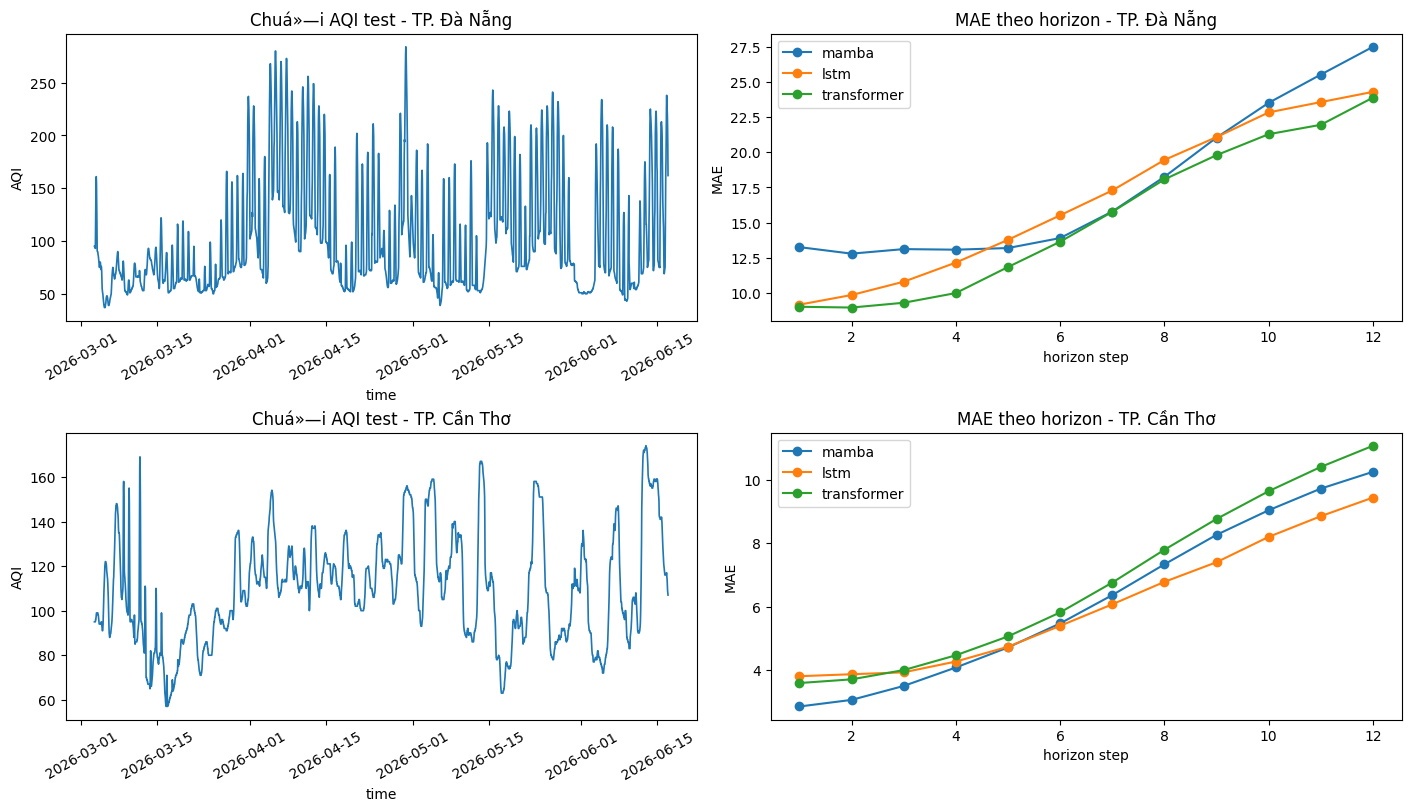

In [17]:
if not HAS_MATPLOTLIB:
    print("matplotlib is not available, skipping plots. Install matplotlib to view charts.")
else:
    fig, axes = plt.subplots(len(FOCUS_PROVINCES), 2, figsize=(14, 4 * len(FOCUS_PROVINCES)), constrained_layout=True)
    if len(FOCUS_PROVINCES) == 1:
        axes = np.array([axes])

    for i, province in enumerate(FOCUS_PROVINCES):
        g = target_series[target_series["province"] == province].sort_values("time")
        ax = axes[i, 0]
        ax.plot(g["time"], g["aqi"], linewidth=1.2)
        ax.set_title(f"Chuá»—i AQI test - {location_name.get(province, province)}")
        ax.set_xlabel("time")
        ax.set_ylabel("AQI")
        ax.tick_params(axis="x", rotation=30)

        ax = axes[i, 1]
        for model in ["mamba", "lstm", "transformer"]:
            h = horizon_err[(horizon_err["province"] == province) & (horizon_err["model"] == model)]
            ax.plot(h["horizon_step"], h["mae"], marker="o", label=model)
        ax.set_title(f"MAE theo horizon - {location_name.get(province, province)}")
        ax.set_xlabel("horizon step")
        ax.set_ylabel("MAE")
        ax.legend()

    plt.show()

In [18]:
series_with_vol = target_series.sort_values(["province", "time"]).copy()
series_with_vol["abs_diff_1h"] = series_with_vol.groupby("province")["aqi"].diff().abs()
series_with_vol["vol_bin"] = series_with_vol.groupby("province")["abs_diff_1h"].transform(
    lambda s: pd.qcut(s.rank(method="first"), q=3, labels=["low", "mid", "high"]) if s.notna().sum() >= 3 else pd.Series(index=s.index, dtype=object)
)

pred_vol = pred.merge(series_with_vol[["province", "time", "abs_diff_1h", "vol_bin"]], on=["province", "time"], how="left")
vol_err = (
    pred_vol.groupby(["province", "province_name", "model", "vol_bin"], as_index=False, observed=True)
    .agg(mae=("abs_error", "mean"), n=("abs_error", "size"), mean_abs_diff_1h=("abs_diff_1h", "mean"))
)

display(vol_err[vol_err["province"].isin(FOCUS_PROVINCES)].pivot_table(index=["province_name", "vol_bin"], columns="model", values="mae"))

model                       lstm      mamba  transformer
province_name vol_bin                                   
TP. Cần Thơ   low       4.943004   4.773676     5.306736
              mid       5.419184   5.345040     5.983293
              high      7.820032   8.540003     8.973981
TP. Đà Nẵng   low       8.531588   9.820984    10.251311
              mid      15.305798  15.666624    15.327870
              high     26.132296  27.278029    20.301539

## 6. Optional: doc Gold/MinIO de bo sung feature goc va chat luong du lieu

Chay cell duoi neu MinIO dang chay va bien moi truong/config cua du an tro dung bucket. Neu khong chay duoc, phan phan tich tu prediction van dung duoc.

In [19]:
def try_collect_gold_features(provinces: list[str], start, end) -> pd.DataFrame:
    import sys
    from datetime import timedelta
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
    from common.minio_io import get_client, load_gold_features

    client = get_client()
    frames = []
    for province in provinces:
        day = pd.Timestamp(start).date()
        end_day = pd.Timestamp(end).date()
        while day <= end_day:
            df = load_gold_features(client, province, day.year, day.month, day.day)
            if df is not None and not df.empty:
                df = df.copy()
                df["province"] = province
                frames.append(df)
            day = day + timedelta(days=1)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


RUN_MINIO_CELL = False
if RUN_MINIO_CELL:
    start = target_series["time"].min()
    end = target_series["time"].max()
    gold = try_collect_gold_features(FOCUS_PROVINCES, start, end)
    print(gold.shape)
    display(gold.head())
else:
    print("Äáº·t RUN_MINIO_CELL = True náº¿u muá»‘n Ä‘á»c thÃªm Gold features tá»« MinIO.")

Äáº·t RUN_MINIO_CELL = True náº¿u muá»‘n Ä‘á»c thÃªm Gold features tá»« MinIO.


In [20]:
if "gold" in globals() and not gold.empty:
    gold["time"] = pd.to_datetime(gold["time"], errors="coerce")
    numeric_cols = [c for c in ["pm25", "pm10", "no2", "o3", "so2", "co", "aod", "dust", "uv_index", "co2", "aqi"] if c in gold.columns]
    flag_cols = [c for c in gold.columns if c.startswith("_flag") or c == "_imputed"]
    gold_summary = gold.groupby("province").agg({
        **{c: ["mean", "std", "min", "max"] for c in numeric_cols},
        **{c: "mean" for c in flag_cols},
    })
    display(gold_summary)
else:
    print("ChÆ°a cÃ³ Gold data trong notebook session.")

ChÆ°a cÃ³ Gold data trong notebook session.


## 7. Tu dong sinh bang ket luan cho bao cao

In [21]:
def explain_row(row: pd.Series) -> str:
    reasons = []
    if pd.notna(row.get("diff_abs_p95")) and row["diff_abs_p95"] >= data_features["diff_abs_p95"].median():
        reasons.append("biáº¿n Ä‘á»™ng/nháº£y báº­c 1h cao")
    if pd.notna(row.get("direction_change_rate")) and row["direction_change_rate"] >= data_features["direction_change_rate"].median():
        reasons.append("Ä‘á»•i hÆ°á»›ng liÃªn tá»¥c")
    if pd.notna(row.get("autocorr_24h")) and row["autocorr_24h"] >= data_features["autocorr_24h"].median():
        reasons.append("chu ká»³ 24h rÃµ")
    if pd.notna(row.get("coverage_ratio")) and row["coverage_ratio"] < 0.98:
        reasons.append("coverage/gap dá»¯ liá»‡u cáº§n kiá»ƒm tra")
    return "; ".join(reasons) if reasons else "khÃ´ng cÃ³ Ä‘áº·c tÃ­nh ná»•i báº­t theo cÃ¡c chá»‰ sá»‘ Ä‘ang xÃ©t"


best_non_mamba = (
    analysis[analysis["model"].isin(["lstm", "transformer"])]
    .sort_values(["province", "delta_mae_vs_mamba"])
    .groupby("province", as_index=False)
    .head(1)
    .copy()
)
best_non_mamba["non_mamba_better"] = best_non_mamba["delta_mae_vs_mamba"] < 0
best_non_mamba["data_evidence"] = best_non_mamba.apply(explain_row, axis=1)

report_table = best_non_mamba[best_non_mamba["province"].isin(FOCUS_PROVINCES)][[
    "province_name", "model", "non_mamba_better", "test_norm_mae", "mamba_mae", "delta_mae_vs_mamba",
    "aqi_std", "diff_abs_p95", "spike_rate", "direction_change_rate", "autocorr_24h", "autocorr_168h", "data_evidence"
]].rename(columns={
    "model": "best_lstm_or_transformer",
    "test_norm_mae": "best_non_mamba_mae",
})

display(report_table)

print("Gá»£i Ã½ cÃ¡ch viáº¿t vÃ o luáº­n vÄƒn/bÃ¡o cÃ¡o:")
for row in report_table.itertuples(index=False):
    relation = "tháº¥p hÆ¡n" if row.delta_mae_vs_mamba < 0 else "chÆ°a tháº¥p hÆ¡n"
    print(
        f"- {row.province_name}: {row.best_lstm_or_transformer} cÃ³ MAE {relation} Mamba "
        f"(delta={row.delta_mae_vs_mamba:.4f}). CÃ¡c Ä‘áº·c tÃ­nh dá»¯ liá»‡u ná»•i báº­t: {row.data_evidence}."
    )

,province_name,best_lstm_or_transformer,non_mamba_better,best_non_mamba_mae,mamba_mae,delta_mae_vs_mamba,aqi_std,diff_abs_p95,spike_rate,direction_change_rate,autocorr_24h,autocorr_168h,data_evidence
9,TP. Cần Thơ,lstm,True,0.172456,0.176960,-0.004504,24.439839,4.0,0.012628,0.140132,0.564134,0.146421,Ä‘á»•i hÆ°á»›ng liÃªn tá»¥c
17,TP. Đà Nẵng,transformer,True,0.299724,0.344588,-0.044864,54.315916,30.0,0.102210,0.139607,0.813326,0.426925,biáº¿n Ä‘á»™ng/nháº£y báº­c 1h cao; Ä‘á»•i hÆ°...


Gá»£i Ã½ cÃ¡ch viáº¿t vÃ o luáº­n vÄƒn/bÃ¡o cÃ¡o:
- TP. Cần Thơ: lstm cÃ³ MAE tháº¥p hÆ¡n Mamba (delta=-0.0045). CÃ¡c Ä‘áº·c tÃ­nh dá»¯ liá»‡u ná»•i báº­t: Ä‘á»•i hÆ°á»›ng liÃªn tá»¥c.
- TP. Đà Nẵng: transformer cÃ³ MAE tháº¥p hÆ¡n Mamba (delta=-0.0449). CÃ¡c Ä‘áº·c tÃ­nh dá»¯ liá»‡u ná»•i báº­t: biáº¿n Ä‘á»™ng/nháº£y báº­c 1h cao; Ä‘á»•i hÆ°á»›ng liÃªn tá»¥c; chu ká»³ 24h rÃµ.


## 8. Xuat bang CSV phuc vu chen vao Word/PowerPoint

In [22]:
OUT_DIR = PROJECT_ROOT / "DataSet" / "EDA" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

data_features.to_csv(OUT_DIR / "province_data_characteristics.csv", index=False, encoding="utf-8-sig")
analysis.to_csv(OUT_DIR / "model_performance_vs_data_characteristics.csv", index=False, encoding="utf-8-sig")
horizon_err.to_csv(OUT_DIR / "horizon_error_by_model_province.csv", index=False, encoding="utf-8-sig")
vol_err.to_csv(OUT_DIR / "volatility_bin_error_by_model_province.csv", index=False, encoding="utf-8-sig")
report_table.to_csv(OUT_DIR / "report_evidence_focus_provinces.csv", index=False, encoding="utf-8-sig")

print("ÄÃ£ xuáº¥t CSV vÃ o:", OUT_DIR)

ÄÃ£ xuáº¥t CSV vÃ o: d:\KLTN\Project\DataSet\EDA\outputs
